In [1]:
import tensorflow as tf
import numpy as np
import optuna
from matplotlib import pyplot as plt
import pandas as pd
import os

# from optuna.visualization.matplotlib import plot_contour, plot_edf, plot_param_importances,\
#         plot_intermediate_values, plot_optimization_history, plot_parallel_coordinate, plot_slice

2023-04-06 08:31:12.165479: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-06 08:31:15.218340: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /global/common/software/nersc/pm-2022q4/sw/evp-patch/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/22.5/math_libs/11.7/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/22.5/cuda/11.7/extras/CUPTI/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/22.5/cuda/11.7/extras/Debugger/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/22.5/cuda/11.7/nvvm/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/22.5/cuda/11.7/lib64:/opt/cray/pe/papi/7.0.0.1/lib64:/

# importing data

In [4]:
df = pd.read_csv('../camels_info/camels_parameters.csv')

out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()

if "LH_603" in sim_names:
    sim_names.remove("LH_603")
    
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]
    
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves)), np.sum(np.isnan(all_cosmologies)))

999
(999, 34, 22) (999, 6)
0 0


# CNN

In [5]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

output_num = 6

# train_y, val_y, test_y = train_y[:,1:2], val_y[:,1:2], test_y[:,1:2]
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)
(849, 6) (100, 6) (50, 6)


In [15]:
input_shape = (34, 22, 1) 

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(512, kernel_size=(2, 2), activation='relu', input_shape=input_shape),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(4, 4), activation='relu'),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=10, validation_data=(val_x, val_y), verbose=1)

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/10
27/27 [==============================] - 9s 286ms/step - loss: 8.5379 - val_loss: 0.2228
Epoch 2/10
27/27 [==============================] - 8s 290ms/step - loss: 0.2212 - val_loss: 0.1831
Epoch 3/10
27/27 [==============================] - 8s 287ms/step - loss: 0.1958 - val_loss: 0.1616
Epoch 4/10
27/27 [==============================] - 8s 293ms/step - loss: 0.1892 - val_loss: 0.1571
Epoch 5/10
27/27 [==============================] - 8s 293ms/step - loss: 0.1680 - val_loss: 0.1449
Epoch 6/10
27/27 [==============================] - 8s 290ms/step - loss: 0.1619 - val_loss: 0.1407
Epoch 7/10
27/27 [==============================] - 8s 285ms/step - loss: 0.1601 - val_loss: 0.1494
Epoch 8/10
27/27 [==============================] - 8s 293ms/step - loss: 0.1626 - val_loss: 0.1415
Epoch 9/10
27/27 [==============================] - 8s 291ms/step - loss: 0.1606 - val_loss: 0.1409
Epoch 10/10
2/2 [==============================] - 0s 72ms/step - loss: 0.1855
Test loss: 0.18551139

2/2 [==============================] - 0s 41ms/step


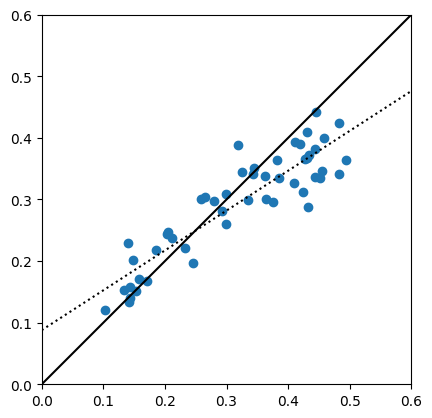

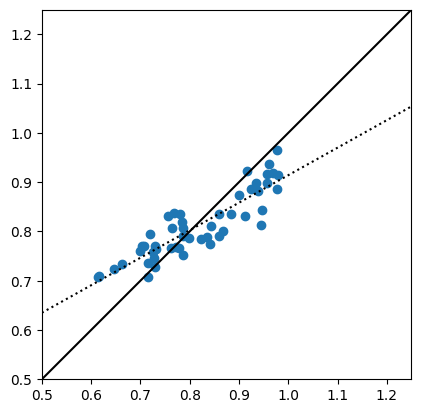

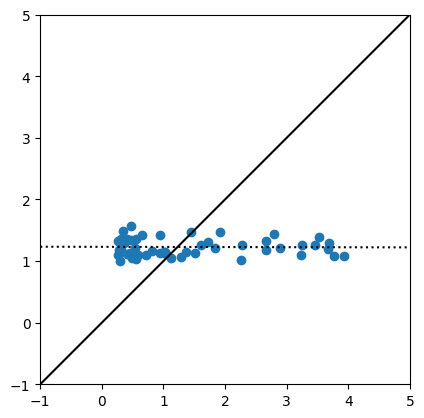

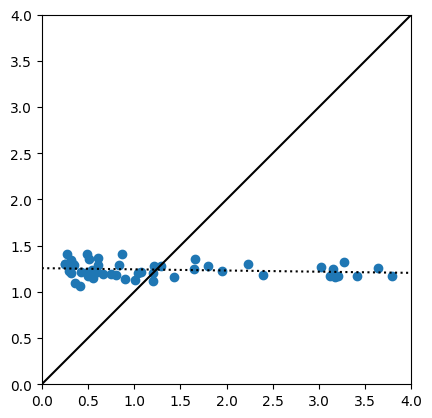

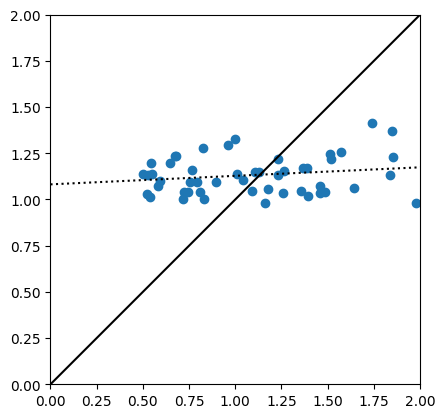

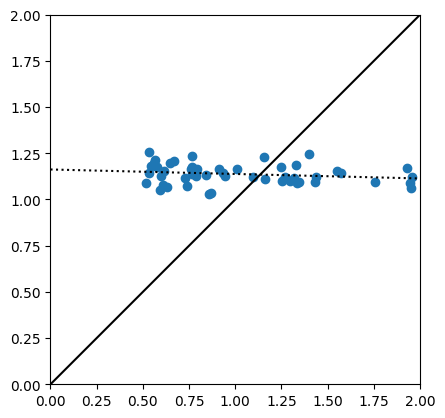

In [16]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

# optuna

In [53]:
input_shape = (34, 22, 1) 

def objective(trial):
    try:
        n_conv_layers = trial.suggest_int('n_conv_layers', 2, 4)
        n_dense_layers = trial.suggest_int('n_dense_layers', 2, 4)

        model = tf.keras.Sequential()
        for i in range(n_conv_layers):
            num_hidden = 2 ** trial.suggest_int(f'log2(n_conv_units_l{i})', 5, 9)
            kernel = trial.suggest_int(f'n_conv_kernel_l{i}', 2, 6)
            if i == 0:
                model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu', input_shape=input_shape))
            else:
                model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu'))
            model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

        model.add(tf.keras.layers.Flatten())

        for i in range(n_dense_layers):
            num_hidden = 2 ** trial.suggest_int(f'log2(n_dense_units_l{i})', 5, 9)
            model.add(tf.keras.layers.Dense(num_hidden, activation='leaky_relu'))

        model.add(tf.keras.layers.Dense(output_num, activation='linear'))

        model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

        history = model.fit(train_x, train_y, epochs=12, verbose=0)

        val_loss = model.evaluate(val_x, val_y, verbose=0)

        return val_loss
    except:
        return np.inf

In [54]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500)

[I 2023-03-20 12:09:58,591] A new study created in memory with name: no-name-d0cfee16-2740-4f2d-bfdf-aeec596bbc39
[I 2023-03-20 12:09:58,617] Trial 0 finished with value: inf and parameters: {'n_conv_layers': 4, 'n_dense_layers': 3, 'log2(n_conv_units_l0)': 8, 'n_conv_kernel_l0': 6, 'log2(n_conv_units_l1)': 5, 'n_conv_kernel_l1': 2, 'log2(n_conv_units_l2)': 8, 'n_conv_kernel_l2': 6}. Best is trial 0 with value: inf.
[I 2023-03-20 12:09:58,641] Trial 1 finished with value: inf and parameters: {'n_conv_layers': 4, 'n_dense_layers': 2, 'log2(n_conv_units_l0)': 7, 'n_conv_kernel_l0': 3, 'log2(n_conv_units_l1)': 6, 'n_conv_kernel_l1': 5, 'log2(n_conv_units_l2)': 8, 'n_conv_kernel_l2': 4}. Best is trial 0 with value: inf.
[I 2023-03-20 12:09:58,669] Trial 2 finished with value: inf and parameters: {'n_conv_layers': 3, 'n_dense_layers': 2, 'log2(n_conv_units_l0)': 8, 'n_conv_kernel_l0': 6, 'log2(n_conv_units_l1)': 9, 'n_conv_kernel_l1': 4, 'log2(n_conv_units_l2)': 8, 'n_conv_kernel_l2': 2}. B

In [55]:
study.best_params, study.best_value

({'n_conv_layers': 2,
  'n_dense_layers': 3,
  'log2(n_conv_units_l0)': 9,
  'n_conv_kernel_l0': 3,
  'log2(n_conv_units_l1)': 9,
  'n_conv_kernel_l1': 2,
  'log2(n_dense_units_l0)': 8,
  'log2(n_dense_units_l1)': 9,
  'log2(n_dense_units_l2)': 8},
 0.13373368978500366)

# plots

/tmp/ipykernel_62398/3324289224.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

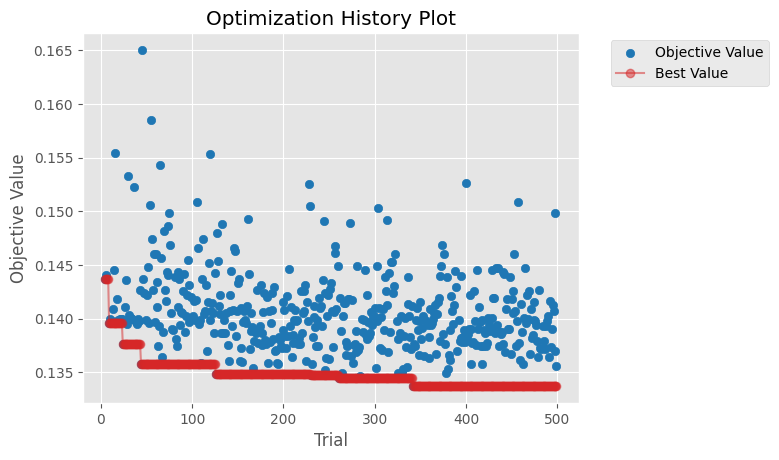

In [56]:
plot_optimization_history(study)

In [58]:
n_conv_layers = study.best_params['n_conv_layers']
n_dense_layers = study.best_params['n_dense_layers']

model = tf.keras.Sequential()
for i in range(n_conv_layers):
    num_hidden = 2 ** study.best_params[f'log2(n_conv_units_l{i})']
    kernel = study.best_params[f'n_conv_kernel_l{i}']
    if i == 0:
        model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu', input_shape=input_shape))
    else:
        model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Flatten())

for i in range(n_dense_layers):
    num_hidden = 2 ** study.best_params[f'log2(n_dense_units_l{i})']
    model.add(tf.keras.layers.Dense(num_hidden, activation='relu'))

model.add(tf.keras.layers.Dense(output_num, activation='linear'))

model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

history = model.fit(train_x, train_y, epochs=12, verbose=1, validation_data=(val_x, val_y))

val_loss = model.evaluate(val_x, val_y, verbose=1)

model.summary()

Epoch 1/12
27/27 [==============================] - 4s 116ms/step - loss: 7.4799 - val_loss: 0.2080
Epoch 2/12
27/27 [==============================] - 3s 115ms/step - loss: 0.2157 - val_loss: 0.1746
Epoch 3/12
27/27 [==============================] - 3s 116ms/step - loss: 0.1917 - val_loss: 0.1593
Epoch 4/12
27/27 [==============================] - 3s 116ms/step - loss: 0.1903 - val_loss: 0.1482
Epoch 5/12
27/27 [==============================] - 3s 120ms/step - loss: 0.1660 - val_loss: 0.1451
Epoch 6/12
27/27 [==============================] - 3s 120ms/step - loss: 0.1604 - val_loss: 0.1538
Epoch 7/12
27/27 [==============================] - 3s 123ms/step - loss: 0.1612 - val_loss: 0.1396
Epoch 8/12
27/27 [==============================] - 3s 120ms/step - loss: 0.1587 - val_loss: 0.1399
Epoch 9/12
27/27 [==============================] - 3s 129ms/step - loss: 0.1577 - val_loss: 0.1365
Epoch 10/12
27/27 [==============================] - 3s 123ms/step - loss: 0.1560 - val_loss: 0.1407

4/4 [==============================] - 0s 14ms/step


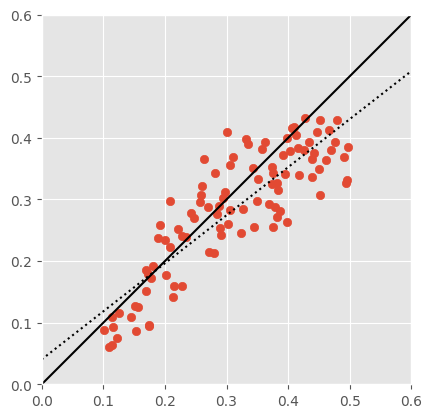

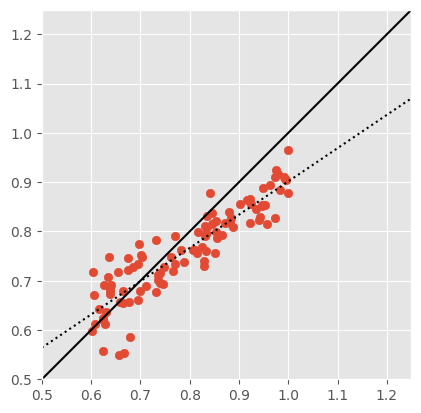

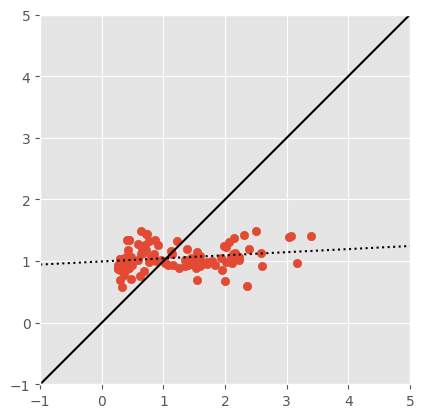

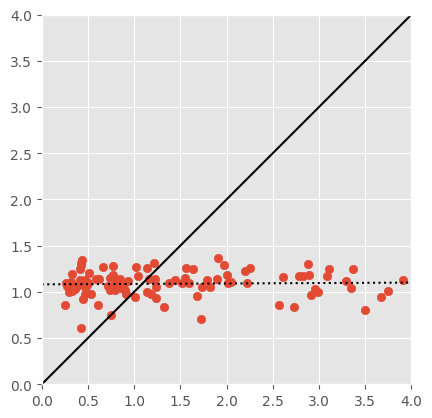

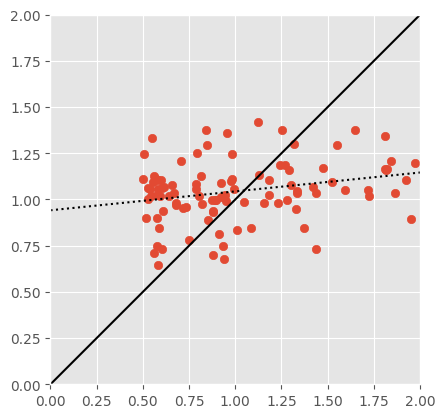

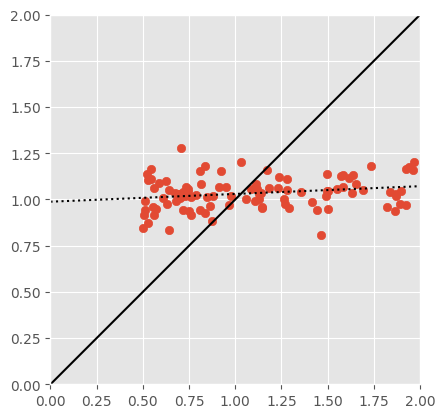

In [59]:
predictions = model.predict(val_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(val_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(val_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

2/2 [==============================] - 0s 11ms/step


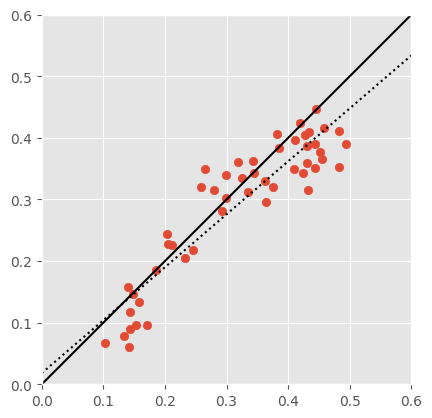

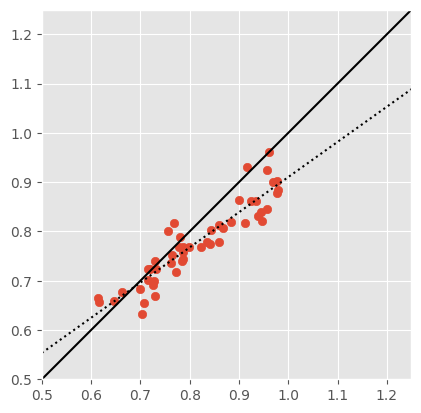

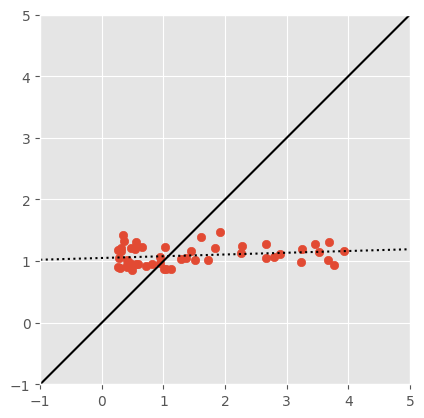

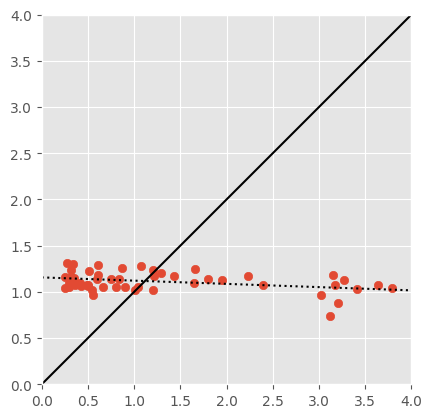

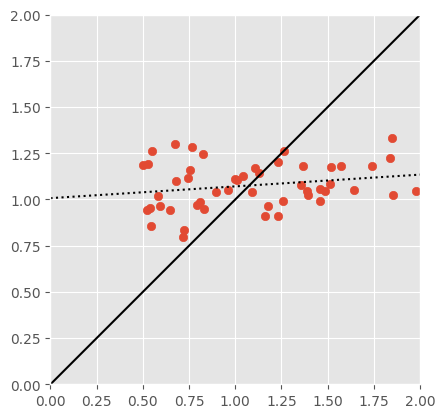

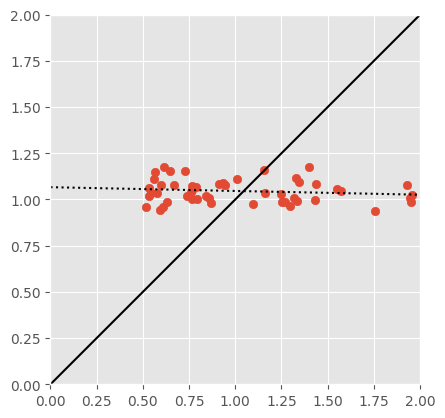

In [60]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

# directly making plots

In [17]:
best_values = {'n_conv_layers': 2,
  'n_dense_layers': 3,
  'log2(n_conv_units_l0)': 9,
  'n_conv_kernel_l0': 3,
  'log2(n_conv_units_l1)': 9,
  'n_conv_kernel_l1': 2,
  'log2(n_dense_units_l0)': 8,
  'log2(n_dense_units_l1)': 9,
  'log2(n_dense_units_l2)': 8}

input_shape = (34, 22, 1)
output_num = 6

In [38]:
n_conv_layers = best_values['n_conv_layers']
n_dense_layers = best_values['n_dense_layers']

model = tf.keras.Sequential()
for i in range(n_conv_layers):
    num_hidden = 2 ** best_values[f'log2(n_conv_units_l{i})']
    kernel = best_values[f'n_conv_kernel_l{i}']
    if i == 0:
        model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu', input_shape=input_shape))
    else:
        model.add(tf.keras.layers.Conv2D(num_hidden, kernel_size=(kernel, kernel), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Flatten())

for i in range(n_dense_layers):
    num_hidden = 2 ** best_values[f'log2(n_dense_units_l{i})']
    model.add(tf.keras.layers.Dense(num_hidden, activation='leaky_relu'))

model.add(tf.keras.layers.Dense(output_num, activation='linear'))

model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

history = model.fit(train_x, train_y, epochs=16, verbose=1, validation_data=(val_x, val_y))

val_loss = model.evaluate(val_x, val_y, verbose=1)

model.summary()

Epoch 1/16
27/27 [==============================] - 4s 112ms/step - loss: 11.3980 - val_loss: 0.2796
Epoch 2/16
27/27 [==============================] - 3s 112ms/step - loss: 0.2112 - val_loss: 0.1711
Epoch 3/16
27/27 [==============================] - 3s 112ms/step - loss: 0.1810 - val_loss: 0.1530
Epoch 4/16
27/27 [==============================] - 3s 112ms/step - loss: 0.1700 - val_loss: 0.1529
Epoch 5/16
27/27 [==============================] - 3s 111ms/step - loss: 0.1653 - val_loss: 0.1428
Epoch 6/16
27/27 [==============================] - 3s 112ms/step - loss: 0.1599 - val_loss: 0.1391
Epoch 7/16
27/27 [==============================] - 3s 110ms/step - loss: 0.1574 - val_loss: 0.1427
Epoch 8/16
27/27 [==============================] - 3s 113ms/step - loss: 0.1569 - val_loss: 0.1368
Epoch 9/16
27/27 [==============================] - 3s 112ms/step - loss: 0.1548 - val_loss: 0.1395
Epoch 10/16
27/27 [==============================] - 3s 110ms/step - loss: 0.1563 - val_loss: 0.139

2/2 [==============================] - 0s 11ms/step


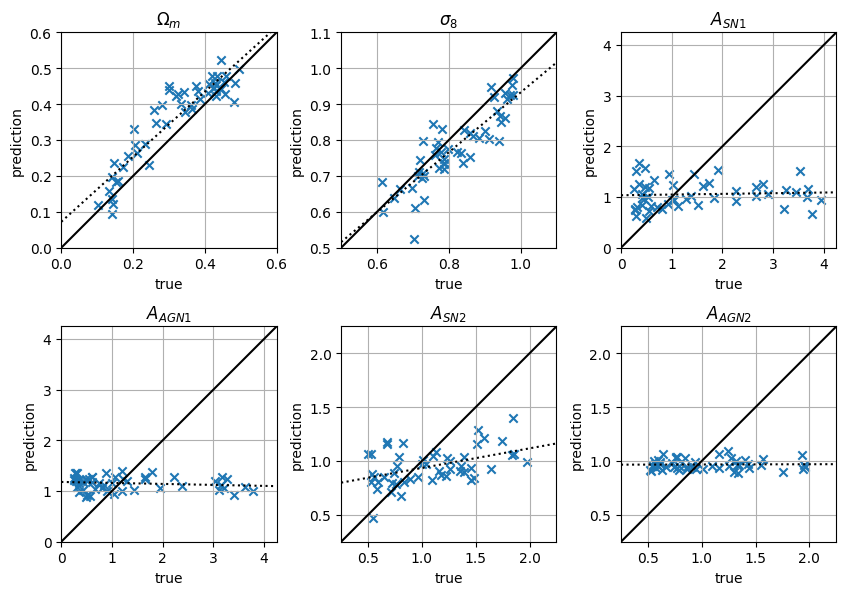

In [42]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.1,4.25,4.25,2.25, 2.25]
low_lims = [0, 0.5, 0, 0, 0.25, 0.25]
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.2)
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$A_{SN1}$", r"$A_{AGN1}$", r"$A_{SN2}$", r"$A_{AGN2}$"]
for ind, (label, ax, low_lim, upp_lim) in enumerate(zip(labels, axs.ravel(), low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    ax.scatter(test_y[:, ind], predictions[:, ind], marker="x")
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    ax.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    ax.set_xlim([low_lim, upp_lim])
    ax.set_ylim([low_lim, upp_lim])
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(label)
    ax.grid()
plt.savefig("../plots/optuna_best.png")
plt.show()
plt.close()